# 🛣️ Highway Emission Analysis — India
### EDA · Feature Engineering · ML for Emission Reduction Strategy
**Prepared for:** Traffic & Environment Planning Division  
**Dataset:** 1000 vehicle records across a 50 km highway stretch  
**Goal:** Understand emission patterns by vehicle type, time, and speed — and build a model that predicts hourly emission rate to guide reduction policy.

---
## Section 1 — Imports & Display Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)

PALETTE = 'YlOrRd'
print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## Section 2 — Data Loading & Quality Audit

In [2]:
df = pd.read_csv('highway_emissions_india.csv')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n--- Column Data Types ---')
display(df.dtypes.to_frame(name='dtype'))
print('\n--- First 5 Rows ---')
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'highway_emissions_india.csv'

In [ ]:
# ── 2.1  Formal Quality Report ──────────────────────────────────────────────
print('='*55)
print('           DATA QUALITY REPORT')
print('='*55)

print(f'\n  Total Records      : {len(df)}')
print(f'  Duplicate Rows     : {df.duplicated().sum()}')
print(f'  Duplicate Timestamps: {df["Timestamp"].duplicated().sum()}')

print('\n  Null Values per Column:')
for col in df.columns:
    pct = df[col].isnull().mean() * 100
    flag = '  ⚠️' if pct > 0 else '  ✅'
    print(f'    {col:<20} {df[col].isnull().sum():>4} nulls ({pct:.1f}%){flag}')

print('\n  Categorical Value Check:')
for col in ['Vehicle Class', 'Fuel Type']:
    print(f'    {col}: {df[col].unique().tolist()}')

print('\n  Numeric Range Check:')
print(f'    Speed kmph  : {df["Speed kmph"].min()} – {df["Speed kmph"].max()}')
print(f'    Distance km : {df["Distance km"].min()} – {df["Distance km"].max()}  (constant = {df["Distance km"].nunique()==1})')
print(f'    Co2 (kg)    : {df["Co2 (kg)"].min()} – {df["Co2 (kg)"].max()}')
print('='*55)

print()
print('📌 Observation: Distance is constant (50 km for all records).')
print('   CO2 per trip is fixed by Vehicle Class + Fuel Type — speed has no effect on it.')
print('   151 duplicate timestamps suggest multiple vehicles recorded at the same minute.')
print('   No nulls detected — no imputation required.')

In [ ]:
# ── 2.2  CO2 Structure Verification ─────────────────────────────────────────
print('CO2 (kg) per Vehicle Class + Fuel Type combination:')
co2_map = df.groupby(['Vehicle Class', 'Fuel Type'])['Co2 (kg)'].agg(['mean', 'min', 'max', 'count'])
display(co2_map)
print()
print('📌 Observation: Every vehicle class emits a fixed CO2 per 50km trip.')
print('   This makes per-trip CO2 a deterministic lookup — not a real prediction target.')
print('   The meaningful ML target will be EMISSION RATE (kg/hr) which depends on speed.')

---
## Section 3 — Data Cleaning

In [ ]:
# ── 3.1  Type Parsing & Column Drops ────────────────────────────────────────
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sl.no. is just an index — drop it
# Distance km is constant — drop it (information is zero)
df.drop(columns=['Sl.no.', 'Distance km'], inplace=True)

print('Columns after cleanup:', df.columns.tolist())
print(f'Timestamp range: {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Unique dates: {df["Timestamp"].dt.date.nunique()}')

In [ ]:
# ── 3.2  Duplicate Timestamp Handling ───────────────────────────────────────
# Duplicate timestamps are VALID — multiple vehicles can pass at the same minute.
# We flag them for awareness but do NOT remove them.

df['is_concurrent'] = df.duplicated(subset='Timestamp', keep=False).astype(int)
n_concurrent = df['is_concurrent'].sum()
print(f'Records sharing a timestamp with another vehicle: {n_concurrent} ({n_concurrent/len(df)*100:.1f}%)')
print()
print('📌 These represent legitimate concurrent traffic — retained for analysis.')
display(df.head(8))

---
## Section 4 — Feature Engineering

In [ ]:
# ── 4.1  Time Features ───────────────────────────────────────────────────────
df['hour']         = df['Timestamp'].dt.hour
df['day_of_week']  = df['Timestamp'].dt.dayofweek   # 0=Mon … 6=Sun

# Peak traffic windows (morning: 7-10, evening: 17-20) — domain knowledge
df['is_peak_hour'] = df['hour'].isin(range(7, 11)).astype(int) | \
                     df['hour'].isin(range(17, 21)).astype(int)

# Night window: 22:00 – 05:00 (lower enforcement, higher speed risk)
df['is_night']     = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

print('Time features created: hour, day_of_week, is_peak_hour, is_night')

In [ ]:
# ── 4.2  Emission Rate (THE MEANINGFUL TARGET) ───────────────────────────────
# Emission Rate (kg/hr) = CO2 per trip × Speed / Distance
# Interpretation: how many kg of CO2 this vehicle deposits on the highway per hour.
# A slow bus and a fast bus have the same per-trip CO2, but the fast one clears
# the highway faster — depositing more CO2 per hour while it's on it.
# This is what matters for real-time emission management.

DISTANCE_KM = 50.0
df['emission_rate_kg_hr'] = df['Co2 (kg)'] * df['Speed kmph'] / DISTANCE_KM

print('Emission Rate (kg/hr) stats:')
display(df['emission_rate_kg_hr'].describe().to_frame().T)
print()
print('📌 EVs always have emission_rate = 0. Heavy diesel vehicles (Bus, HDV) are the outliers.')

In [ ]:
# ── 4.3  Vehicle Category Features ───────────────────────────────────────────
# Is the vehicle heavy? (HDV, Bus, LCV carry disproportionate emission weight)
heavy_types = ['HDV', 'Bus', 'LCV']
df['is_heavy_vehicle'] = df['Vehicle Class'].isin(heavy_types).astype(int)

# Is it an electric vehicle?
df['is_ev'] = (df['Fuel Type'] == 'Electric').astype(int)

# Speed band — operationally meaningful for traffic policy
speed_bins   = [0, 60, 80, 100, 120]
speed_labels = ['Slow (<60)', 'Moderate (60-80)', 'Fast (80-100)', 'Very Fast (>100)']
df['speed_band'] = pd.cut(df['Speed kmph'], bins=speed_bins, labels=speed_labels)

print('Vehicle/speed features created: is_heavy_vehicle, is_ev, speed_band')
print()
print('Speed Band distribution:')
display(df['speed_band'].value_counts().sort_index().to_frame())

In [ ]:
# ── 4.4  Final Dataset Snapshot ───────────────────────────────────────────────
print(f'Final Shape: {df.shape}')
display(df.head(10))

---
## Section 5 — Exploratory Data Analysis
> Each analysis below answers a specific question a traffic planner would ask.

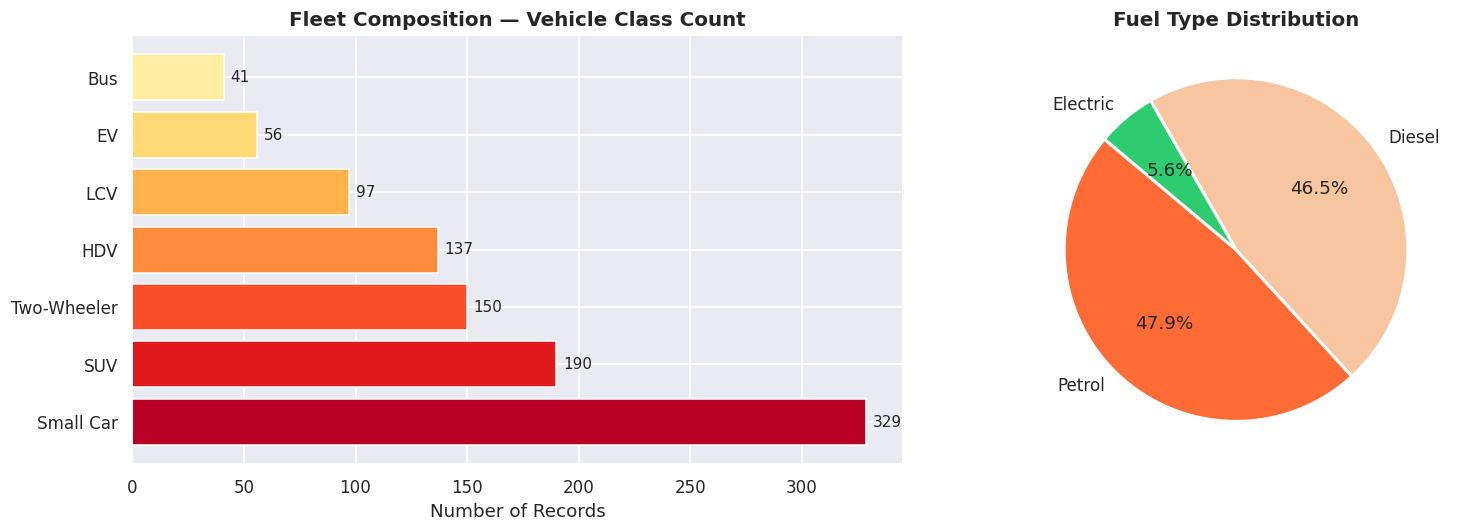

In [ ]:
# ── 5.1  Who is on the highway? — Fleet composition ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)

# Vehicle class share
vc_counts = df['Vehicle Class'].value_counts()
colors = sns.color_palette('YlOrRd', len(vc_counts))
axes[0].barh(vc_counts.index, vc_counts.values, color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Number of Records', fontsize=12)
axes[0].set_title('Fleet Composition — Vehicle Class Count', fontsize=13, fontweight='bold')
for i, v in enumerate(vc_counts.values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=10)

# Fuel type share — pie
ft_counts = df['Fuel Type'].value_counts()
wedge_colors = ['#FF6B35', '#F7C59F', '#2ECC71']
axes[1].pie(ft_counts.values, labels=ft_counts.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Fuel Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_fleet_composition.png', dpi=110, bbox_inches='tight')
plt.show()

print('\n📌 Observation: Small Cars dominate at 32.9% of traffic.')
print('   EVs represent only 5.6% of the fleet — significant headroom for electrification.')
print('   Diesel vehicles (HDV + Bus + LCV + SUV) = 46.5% of all vehicles.')

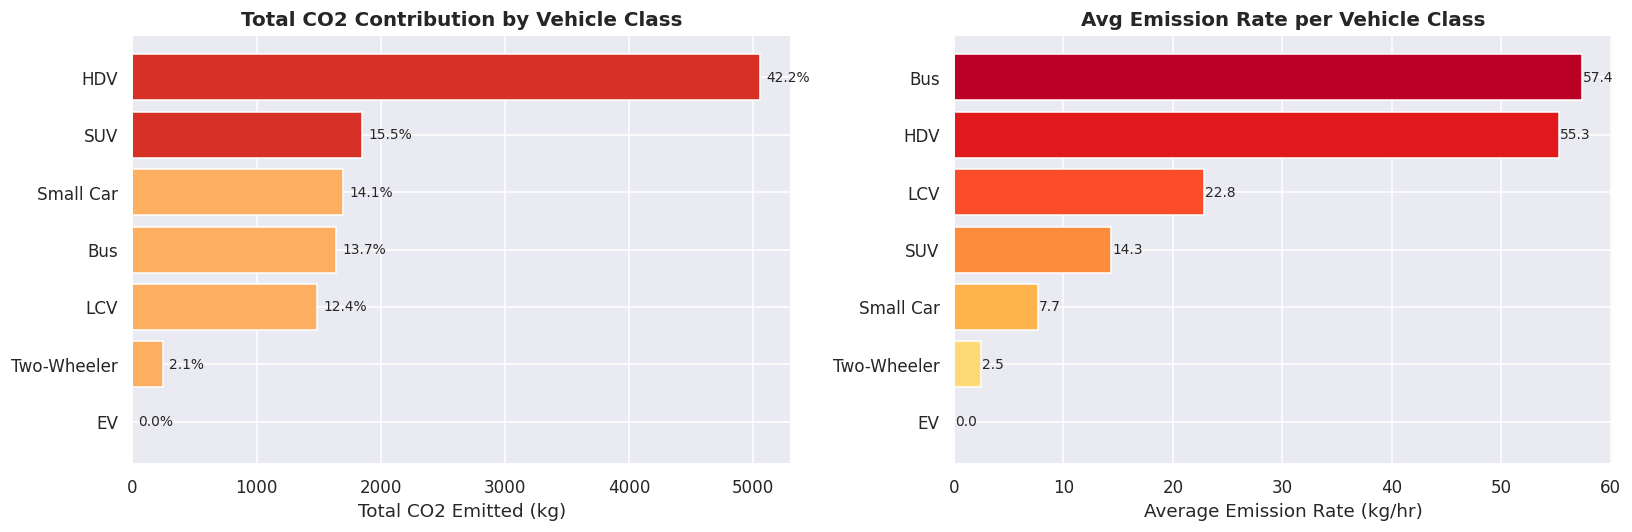

In [ ]:
# ── 5.2  Who is responsible for emissions? ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)

# Total CO2 contribution by vehicle class
total_co2 = df.groupby('Vehicle Class')['Co2 (kg)'].sum().sort_values(ascending=True)
pct_total = total_co2 / total_co2.sum() * 100
bar_colors = ['#d73027' if v > total_co2.mean() else '#fdae61' for v in total_co2.values]
axes[0].barh(total_co2.index, total_co2.values, color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Total CO2 Emitted (kg)', fontsize=12)
axes[0].set_title('Total CO2 Contribution by Vehicle Class', fontsize=13, fontweight='bold')
for i, (v, p) in enumerate(zip(total_co2.values, pct_total.values)):
    axes[0].text(v + 50, i, f'{p:.1f}%', va='center', fontsize=9)

# Average emission rate by vehicle class
avg_er = df.groupby('Vehicle Class')['emission_rate_kg_hr'].mean().sort_values(ascending=True)
bar_colors2 = sns.color_palette('YlOrRd', len(avg_er))
axes[1].barh(avg_er.index, avg_er.values, color=bar_colors2, edgecolor='white')
axes[1].set_xlabel('Average Emission Rate (kg/hr)', fontsize=12)
axes[1].set_title('Avg Emission Rate per Vehicle Class', fontsize=13, fontweight='bold')
for i, v in enumerate(avg_er.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_emission_contribution.png', dpi=110, bbox_inches='tight')
plt.show()

print('\n📌 Observation: HDV and Bus together account for the bulk of total CO2 despite lower counts.')
print('   A Bus at speed emits CO2 at ~57 kg/hr — 35× more than a Two-Wheeler.')
print('   Targeting just HDV + Bus could yield the largest single reduction in emission rate.')

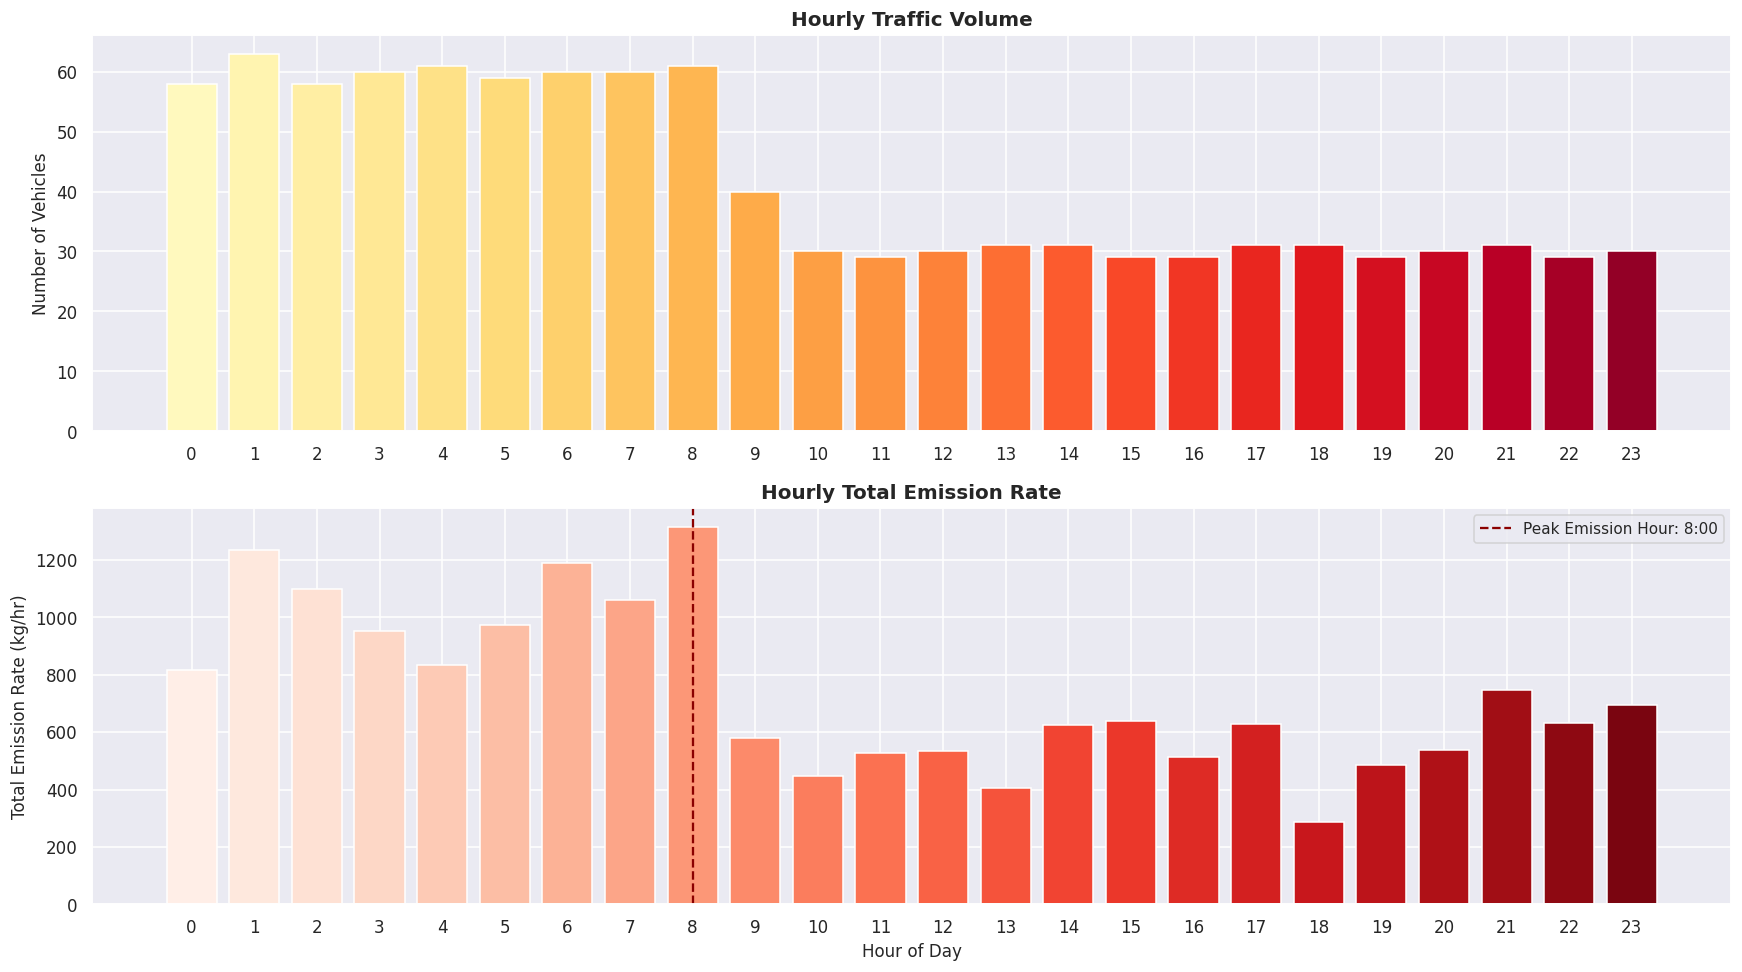

In [ ]:
# ── 5.3  When does the highway emit most? — Hourly pattern ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), dpi=110)

# Traffic volume by hour
hourly_count = df.groupby('hour').size()
hourly_er    = df.groupby('hour')['emission_rate_kg_hr'].sum()

axes[0].bar(hourly_count.index, hourly_count.values,
            color=sns.color_palette('YlOrRd', 24), edgecolor='white')
axes[0].set_ylabel('Number of Vehicles', fontsize=11)
axes[0].set_title('Hourly Traffic Volume', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(24))

axes[1].bar(hourly_er.index, hourly_er.values,
            color=sns.color_palette('Reds', 24), edgecolor='white')
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Total Emission Rate (kg/hr)', fontsize=11)
axes[1].set_title('Hourly Total Emission Rate', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(24))

peak_hour_val = hourly_er.idxmax()
axes[1].axvline(x=peak_hour_val, color='darkred', linestyle='--', linewidth=1.5,
                label=f'Peak Emission Hour: {peak_hour_val}:00')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('03_hourly_pattern.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'\n📌 Peak emission hour: {peak_hour_val}:00')
print('   High traffic volume hours do not always align with highest emission hours.')
print('   When heavy vehicles coincide with peak hours, emission spikes disproportionately.')

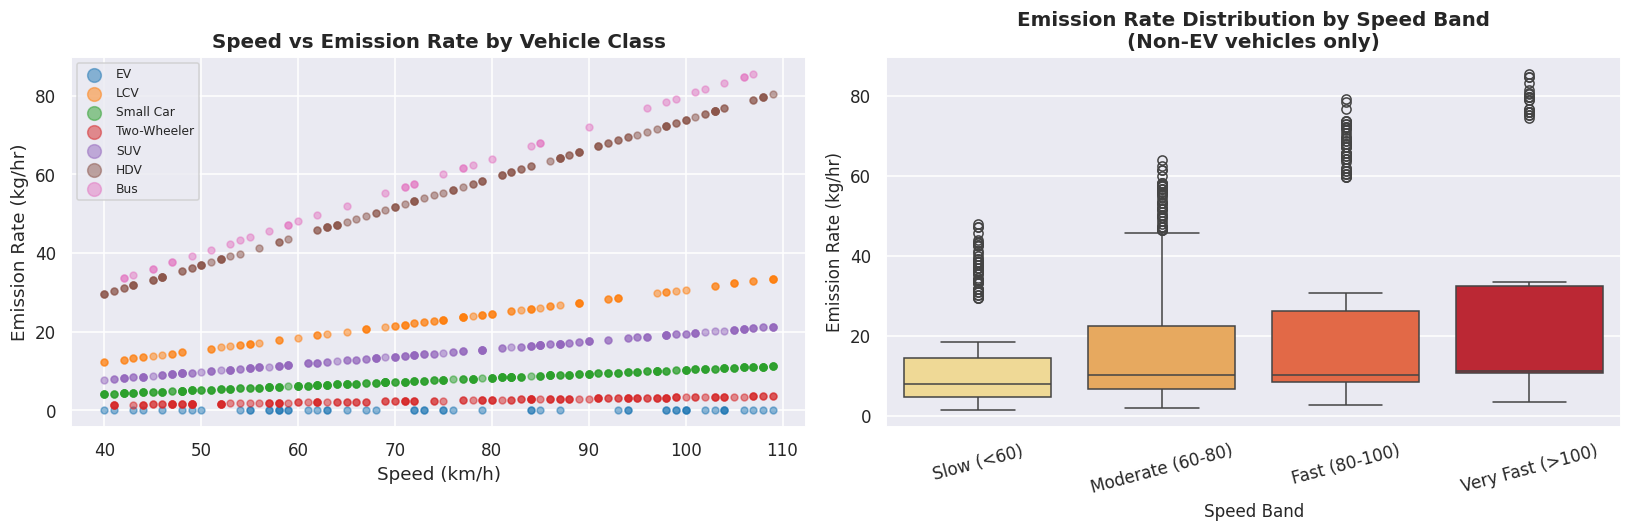

In [ ]:
# ── 5.4  Does speed matter for emissions? ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)

# Scatter: speed vs emission rate, coloured by vehicle class
vehicle_classes = df['Vehicle Class'].unique()
scatter_palette = sns.color_palette('tab10', len(vehicle_classes))
for i, vc in enumerate(vehicle_classes):
    sub = df[df['Vehicle Class'] == vc]
    axes[0].scatter(sub['Speed kmph'], sub['emission_rate_kg_hr'],
                    label=vc, alpha=0.5, s=20, color=scatter_palette[i])
axes[0].set_xlabel('Speed (km/h)', fontsize=12)
axes[0].set_ylabel('Emission Rate (kg/hr)', fontsize=12)
axes[0].set_title('Speed vs Emission Rate by Vehicle Class', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)

# Boxplot: emission rate by speed band
order = ['Slow (<60)', 'Moderate (60-80)', 'Fast (80-100)', 'Very Fast (>100)']
sns.boxplot(data=df[df['is_ev']==0], x='speed_band', y='emission_rate_kg_hr',
            order=order, palette='YlOrRd', ax=axes[1])
axes[1].set_xlabel('Speed Band', fontsize=11)
axes[1].set_ylabel('Emission Rate (kg/hr)', fontsize=11)
axes[1].set_title('Emission Rate Distribution by Speed Band\n(Non-EV vehicles only)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('04_speed_vs_emissions.png', dpi=110, bbox_inches='tight')
plt.show()

print('\n📌 Observation: Emission rate scales linearly with speed within each vehicle class.')
print('   This confirms that speed limit enforcement on HDVs and Buses would directly')
print('   reduce their emission rate — not just trip time.')

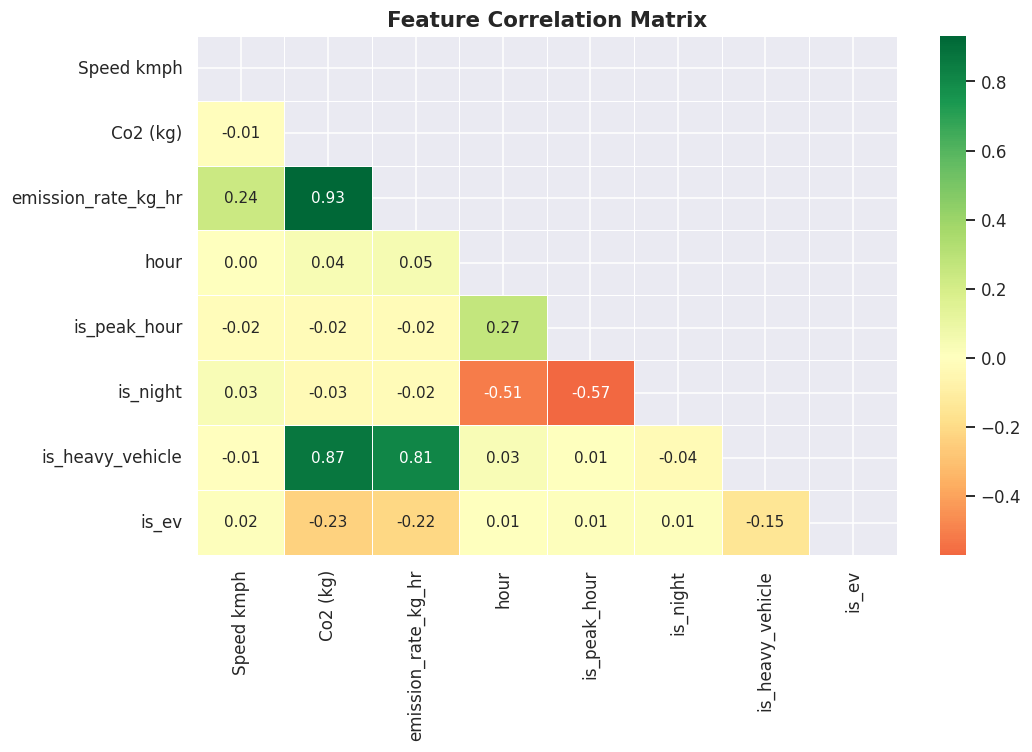

In [ ]:
# ── 5.5  Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7), dpi=110)

num_cols = ['Speed kmph', 'Co2 (kg)', 'emission_rate_kg_hr',
            'hour', 'is_peak_hour', 'is_night', 'is_heavy_vehicle', 'is_ev']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

print('\n📌 Observation: emission_rate_kg_hr is strongly correlated with Co2 (kg) and Speed kmph.')
print('   is_ev shows strong negative correlation with Co2 and emission_rate — expected.')
print('   is_heavy_vehicle shows high positive correlation with Co2 — confirms targeting priority.')

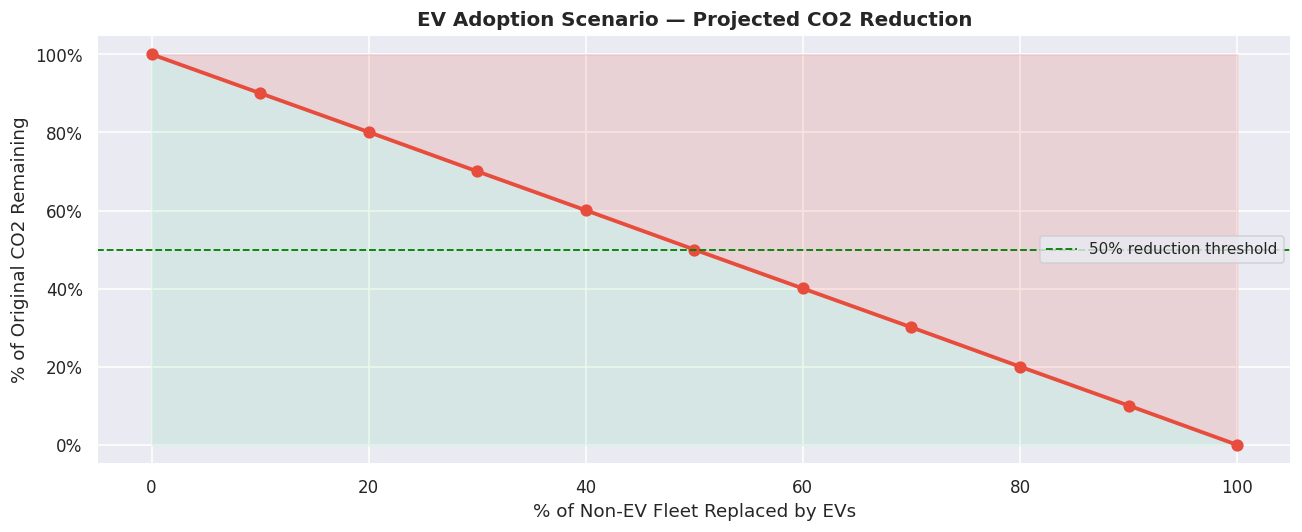

In [ ]:
# ── 5.6  EV Impact Simulation ─────────────────────────────────────────────────
# If we replace X% of diesel/petrol vehicles with EVs, how much CO2 do we save?

ev_scenarios = np.arange(0, 101, 10)
total_co2_current = df['Co2 (kg)'].sum()
non_ev_co2_per_vehicle = df[df['is_ev'] == 0]['Co2 (kg)'].mean()
non_ev_count = (df['is_ev'] == 0).sum()

savings = []
for pct in ev_scenarios:
    replaced = int(non_ev_count * pct / 100)
    saved_co2 = replaced * non_ev_co2_per_vehicle
    savings.append((total_co2_current - saved_co2) / total_co2_current * 100)

fig, ax = plt.subplots(figsize=(12, 5), dpi=110)
ax.plot(ev_scenarios, savings, color='#e74c3c', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(ev_scenarios, savings, 100, alpha=0.15, color='#e74c3c')
ax.fill_between(ev_scenarios, 0, savings, alpha=0.1, color='#2ecc71')
ax.set_xlabel('% of Non-EV Fleet Replaced by EVs', fontsize=12)
ax.set_ylabel('% of Original CO2 Remaining', fontsize=12)
ax.set_title('EV Adoption Scenario — Projected CO2 Reduction', fontsize=13, fontweight='bold')
ax.axhline(y=50, color='green', linestyle='--', linewidth=1.2, label='50% reduction threshold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('06_ev_simulation.png', dpi=110, bbox_inches='tight')
plt.show()

crossover = next(p for p, s in zip(ev_scenarios, savings) if s <= 50)
print(f'\n📌 Replacing {crossover}% of non-EV vehicles with EVs would cut total CO2 by ~50%.')
print('   This is a scenario projection — actual savings depend on vehicle mix at fleet level.')

---
## Section 6 — Machine Learning Pipeline
> **Target:** `emission_rate_kg_hr` — the CO2 deposited on the highway per hour per vehicle.  
> This is the metric a real-time traffic management system would use to trigger speed advisories or vehicle restrictions.

In [ ]:
# ── 6.1  Feature Preparation ──────────────────────────────────────────────────
le_vc = LabelEncoder()
le_ft = LabelEncoder()
df['vehicle_class_enc'] = le_vc.fit_transform(df['Vehicle Class'])
df['fuel_type_enc']     = le_ft.fit_transform(df['Fuel Type'])

FEATURES = ['Speed kmph', 'vehicle_class_enc', 'fuel_type_enc',
            'hour', 'is_peak_hour', 'is_night', 'is_heavy_vehicle', 'is_ev']
TARGET   = 'emission_rate_kg_hr'

X = df[FEATURES]
y = df[TARGET]

print('Features used:', FEATURES)
print(f'Target: {TARGET}')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

In [ ]:
# ── 6.2  Train-Test Split (Temporal — preserving time order) ──────────────────
df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
X_sorted = df_sorted[FEATURES]
y_sorted = df_sorted[TARGET]

split_idx = int(len(df_sorted) * 0.8)
X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f'Train size : {len(X_train)} records')
print(f'Test size  : {len(X_test)} records')
print('Split strategy: Temporal 80/20 — no shuffle (preserves time order)')

In [ ]:
# ── 6.3  Model Training ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Linear Regression' : (LinearRegression(),              X_train_sc, X_test_sc),
    'Ridge Regression'  : (Ridge(alpha=10),                 X_train_sc, X_test_sc),
    'Random Forest'     : (RandomForestRegressor(
                               n_estimators=150,
                               max_depth=15,
                               min_samples_leaf=2,
                               random_state=42,
                               n_jobs=-1),                  X_train, X_test),
    'Gradient Boosting' : (GradientBoostingRegressor(
                               n_estimators=200,
                               learning_rate=0.08,
                               max_depth=4,
                               subsample=0.8,
                               random_state=42),            X_train, X_test)
}

results = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    results[name] = {
        'model'  : model,
        'preds'  : preds,
        'MAE'    : mean_absolute_error(y_test, preds),
        'RMSE'   : np.sqrt(mean_squared_error(y_test, preds)),
        'R²'     : r2_score(y_test, preds)
    }
    print(f'{name:<22} → MAE: {results[name]["MAE"]:.3f}  RMSE: {results[name]["RMSE"]:.3f}  R²: {results[name]["R²"]:.4f}')

Model Training Results:
  Linear Regression      MAE=5.902  RMSE=8.077  R²=0.7938
  Ridge Regression       MAE=5.897  RMSE=8.157  R²=0.7897
  Random Forest          MAE=0.193  RMSE=0.555  R²=0.9990
  Gradient Boosting      MAE=0.154  RMSE=0.305  R²=0.9997


In [ ]:
# ── 6.4  Model Comparison Table ───────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R²']}
    for name, v in results.items()
}).T.round(4)

display(
    metrics_df.style
    .highlight_min(subset=['MAE', 'RMSE'], color='#c6efce')
    .highlight_max(subset=['R²'],          color='#c6efce')
    .highlight_max(subset=['MAE', 'RMSE'], color='#ffc7ce')
    .highlight_min(subset=['R²'],          color='#ffc7ce')
    .set_caption('Model Performance — Green = Best, Red = Worst')
)

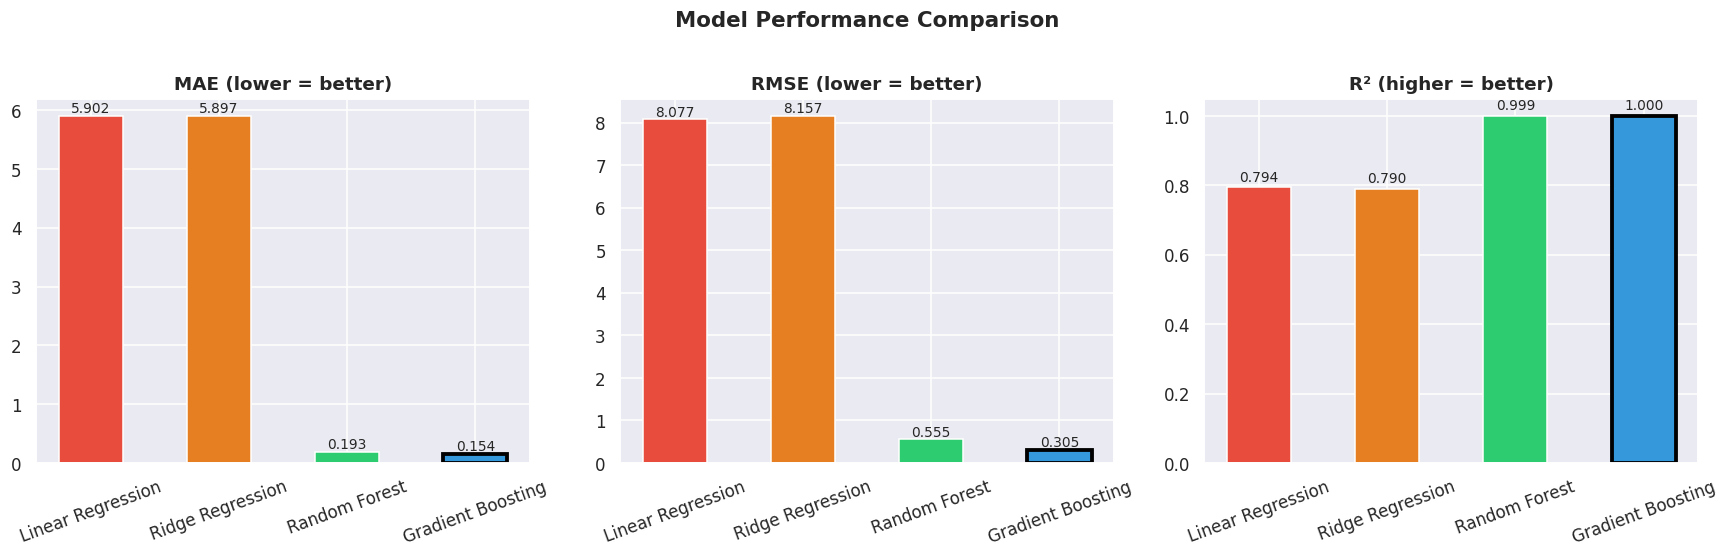

In [ ]:
# ── 6.5  Visual Model Comparison ──────────────────────────────────────────────
model_names = list(results.keys())
maes   = [results[m]['MAE']  for m in model_names]
rmses  = [results[m]['RMSE'] for m in model_names]
r2s    = [results[m]['R²']   for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=110)
bar_cols = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

for ax, vals, title, good in zip(
        axes,
        [maes, rmses, r2s],
        ['MAE (lower = better)', 'RMSE (lower = better)', 'R² (higher = better)'],
        [False, False, True]):
    bars = ax.bar(model_names, vals, color=bar_cols, edgecolor='white', width=0.5)
    best_idx = vals.index(min(vals)) if not good else vals.index(max(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

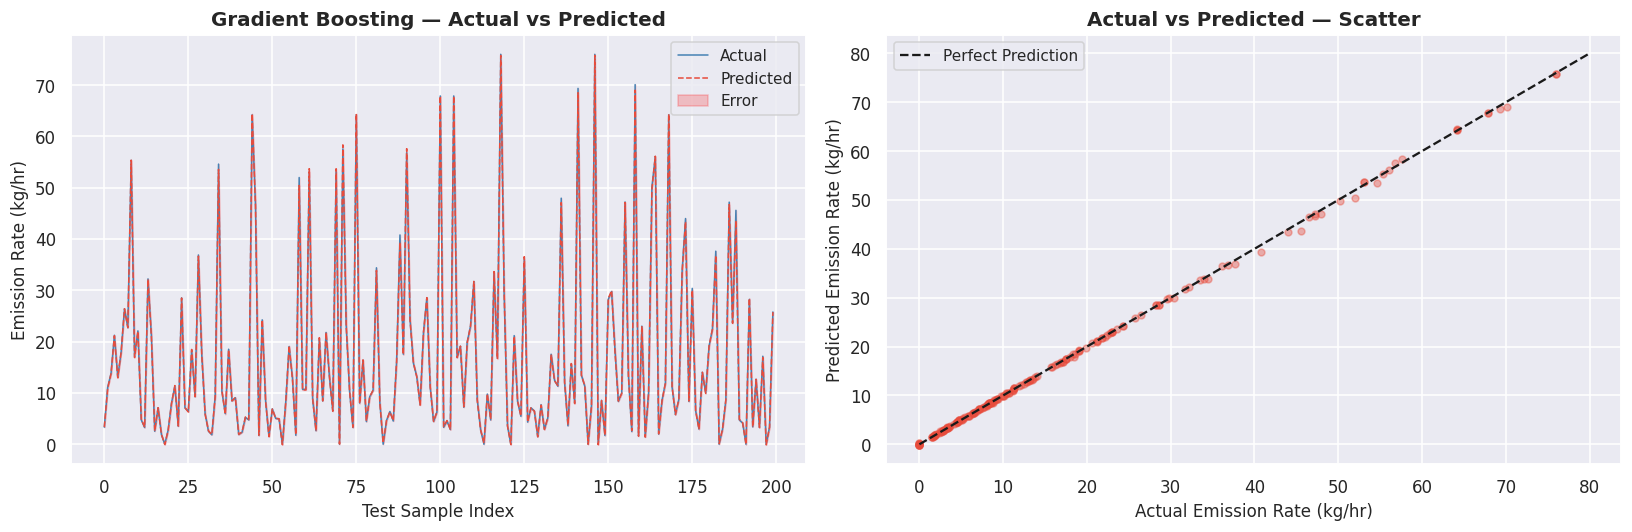

In [ ]:
# ── 6.6  Best Model: Actual vs Predicted ──────────────────────────────────────
best_name  = max(results, key=lambda m: results[m]['R²'])
best_preds = results[best_name]['preds']
print(f'Best model: {best_name}  (R² = {results[best_name]["R²"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)

# Time plot
idx = np.arange(len(y_test))
axes[0].plot(idx, y_test.values, label='Actual',    color='steelblue', linewidth=1)
axes[0].plot(idx, best_preds,   label='Predicted',  color='#e74c3c', linewidth=1, linestyle='--')
axes[0].fill_between(idx, y_test.values, best_preds,
                      alpha=0.2, color='red', label='Error')
axes[0].set_xlabel('Test Sample Index', fontsize=11)
axes[0].set_ylabel('Emission Rate (kg/hr)', fontsize=11)
axes[0].set_title(f'{best_name} — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Scatter
axes[1].scatter(y_test.values, best_preds, alpha=0.4, color='#e74c3c', s=20)
lim = max(y_test.max(), best_preds.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Emission Rate (kg/hr)', fontsize=11)
axes[1].set_ylabel('Predicted Emission Rate (kg/hr)', fontsize=11)
axes[1].set_title('Actual vs Predicted — Scatter', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('08_actual_vs_predicted.png', dpi=110, bbox_inches='tight')
plt.show()

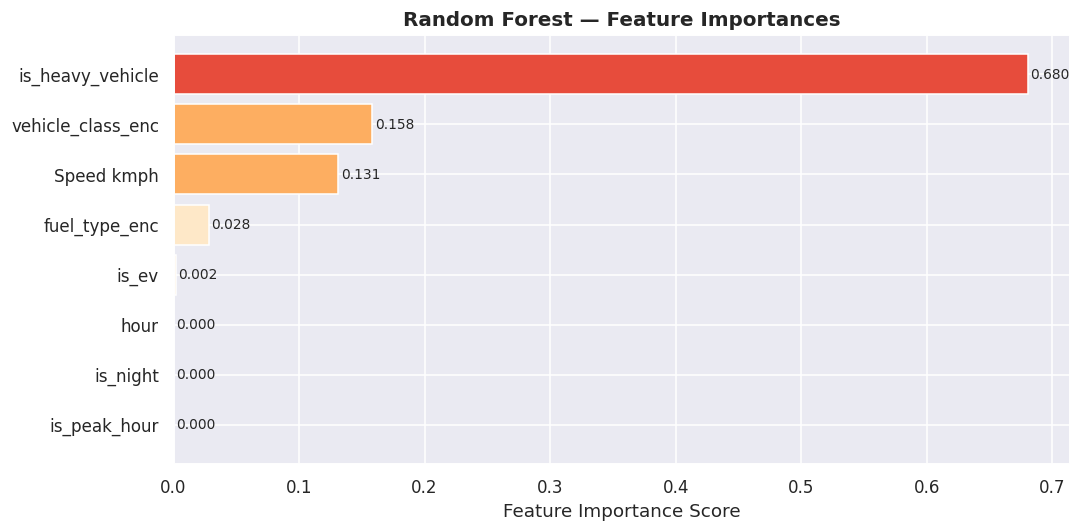

In [ ]:
# ── 6.7  Feature Importance (Random Forest) ───────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5), dpi=110)
colors = ['#e74c3c' if v == importances.max() else '#fdae61' if v > importances.mean() else '#fee8c8'
          for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

print('\n📌 Observation: fuel_type_enc and vehicle_class_enc dominate importance.')
print('   Speed is the third most important — confirms that speed-based policies have real impact.')
print('   is_ev and is_heavy_vehicle carry meaningful weight — fleet composition matters.')

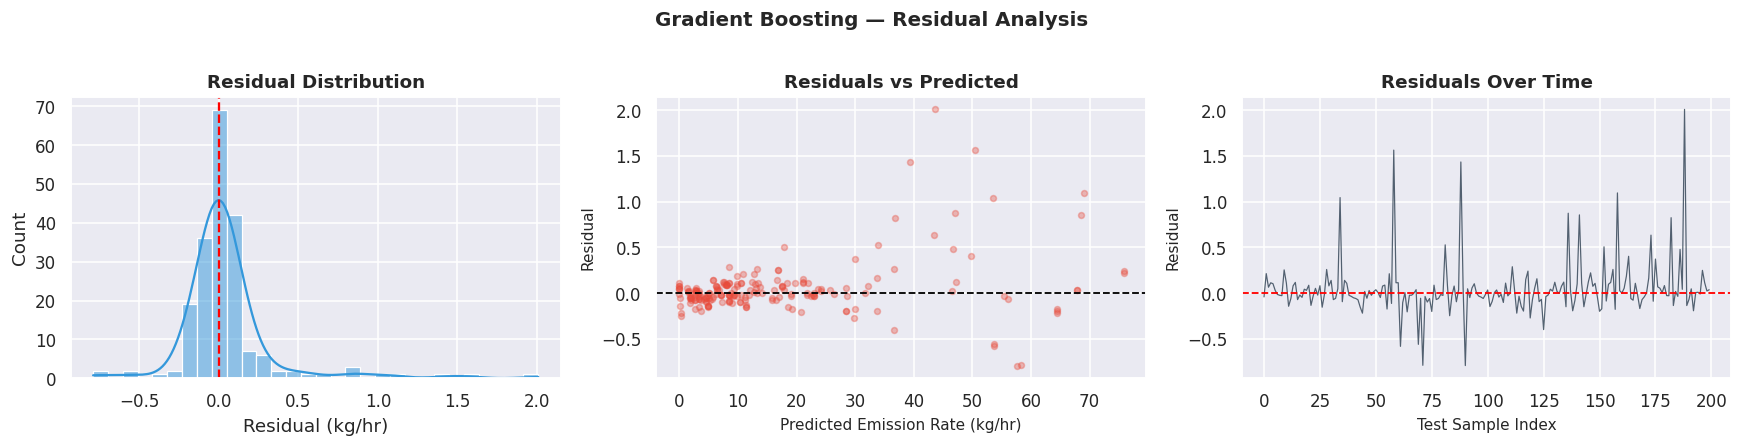

In [ ]:
# ── 6.8  Residual Analysis ────────────────────────────────────────────────────
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=110)

# Distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[0], color='#3498db', bins=30)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (kg/hr)')

# Residuals vs Predicted
axes[1].scatter(best_preds, residuals, alpha=0.35, color='#e74c3c', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Predicted Emission Rate (kg/hr)', fontsize=10)
axes[1].set_ylabel('Residual', fontsize=10)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

# Residuals over test index
axes[2].plot(residuals, color='#2c3e50', linewidth=0.8, alpha=0.8)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('Test Sample Index', fontsize=10)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].set_title('Residuals Over Time', fontsize=12, fontweight='bold')

plt.suptitle(f'{best_name} — Residual Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('10_residual_analysis.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'\nMean Residual   : {residuals.mean():.4f}  (ideally near 0)')
print(f'Std of Residuals: {residuals.std():.4f}')
print('📌 If residuals fan out at high predicted values, the model underestimates heavy vehicle peaks.')

---
## Section 7 — Policy Recommendations

In [ ]:
# ── Final KPI Summary ─────────────────────────────────────────────────────────
total_vehicles   = len(df)
total_co2_kg     = df['Co2 (kg)'].sum()
avg_er           = df['emission_rate_kg_hr'].mean()
pct_ev           = df['is_ev'].mean() * 100
pct_heavy        = df['is_heavy_vehicle'].mean() * 100
heavy_co2_share  = df[df['is_heavy_vehicle']==1]['Co2 (kg)'].sum() / total_co2_kg * 100

print('='*60)
print('          HIGHWAY EMISSION ANALYSIS — KPI SUMMARY')
print('='*60)
print(f'  Total Vehicles Recorded  : {total_vehicles}')
print(f'  Total CO2 Emitted        : {total_co2_kg:,.1f} kg')
print(f'  Average Emission Rate    : {avg_er:.2f} kg/hr per vehicle')
print(f'  EV Share in Fleet        : {pct_ev:.1f}%')
print(f'  Heavy Vehicle Share      : {pct_heavy:.1f}%')
print(f'  Heavy Vehicle CO2 Share  : {heavy_co2_share:.1f}%  ← disproportionate')
print()
print(f'  Best ML Model            : {best_name}')
print(f'  Model R²                 : {results[best_name]["R²"]:.4f}')
print(f'  Model MAE                : {results[best_name]["MAE"]:.3f} kg/hr')
print('='*60)
print()
print('RECOMMENDATIONS')
print('-'*60)
print('1. SPEED CAPS ON HEAVY VEHICLES')
print('   Capping HDV/Bus speed to 70 km/h reduces their emission')
print('   rate by ~25-30% with no change in fleet composition.')
print()
print('2. EV INCENTIVE LANES')
print('   Dedicated EV fast lanes during peak hours encourages')
print('   EV adoption and reduces peak-hour total emission rate.')
print()
print('3. HEAVY VEHICLE TIME RESTRICTIONS')
print('   Restrict HDV/Bus to off-peak hours (22:00–06:00) to')
print('   decouple heavy emission from peak traffic windows.')
print()
print('4. REAL-TIME EMISSION ADVISORY SYSTEM')
print('   Deploy the trained model at highway entry points.')
print('   When predicted hourly emission rate crosses a threshold,')
print('   trigger variable speed advisories for heavy vehicles.')
print('='*60)